In [63]:
import pandas as pd
import pygmt
import xarray as xr
import numpy as np

In [64]:
def plot_basemap(region, feature=True, projection="M12c"):
    fig = pygmt.Figure()
    if feature:
        fig.coast(
            region=region,
            projection=projection,
            frame=["xaf", "yaf", "WSen"],
            shorelines="0.8p,black",
            land="gray92",
            water="white",
        )
    else:
        fig.basemap(region=region, projection=projection, frame=["xaf", "yaf", "WSen"])
        fig.coast(shorelines="0.8p,black")
    return fig

In [65]:
region = [-156.3, -154.7, 18.8, 20.4]
sr = pd.read_csv("src_rec_file_raw.csv")



In [68]:
! gmt grdcut @earth_relief_01m -R-157/-152/18/21 -Ghawaii.nc

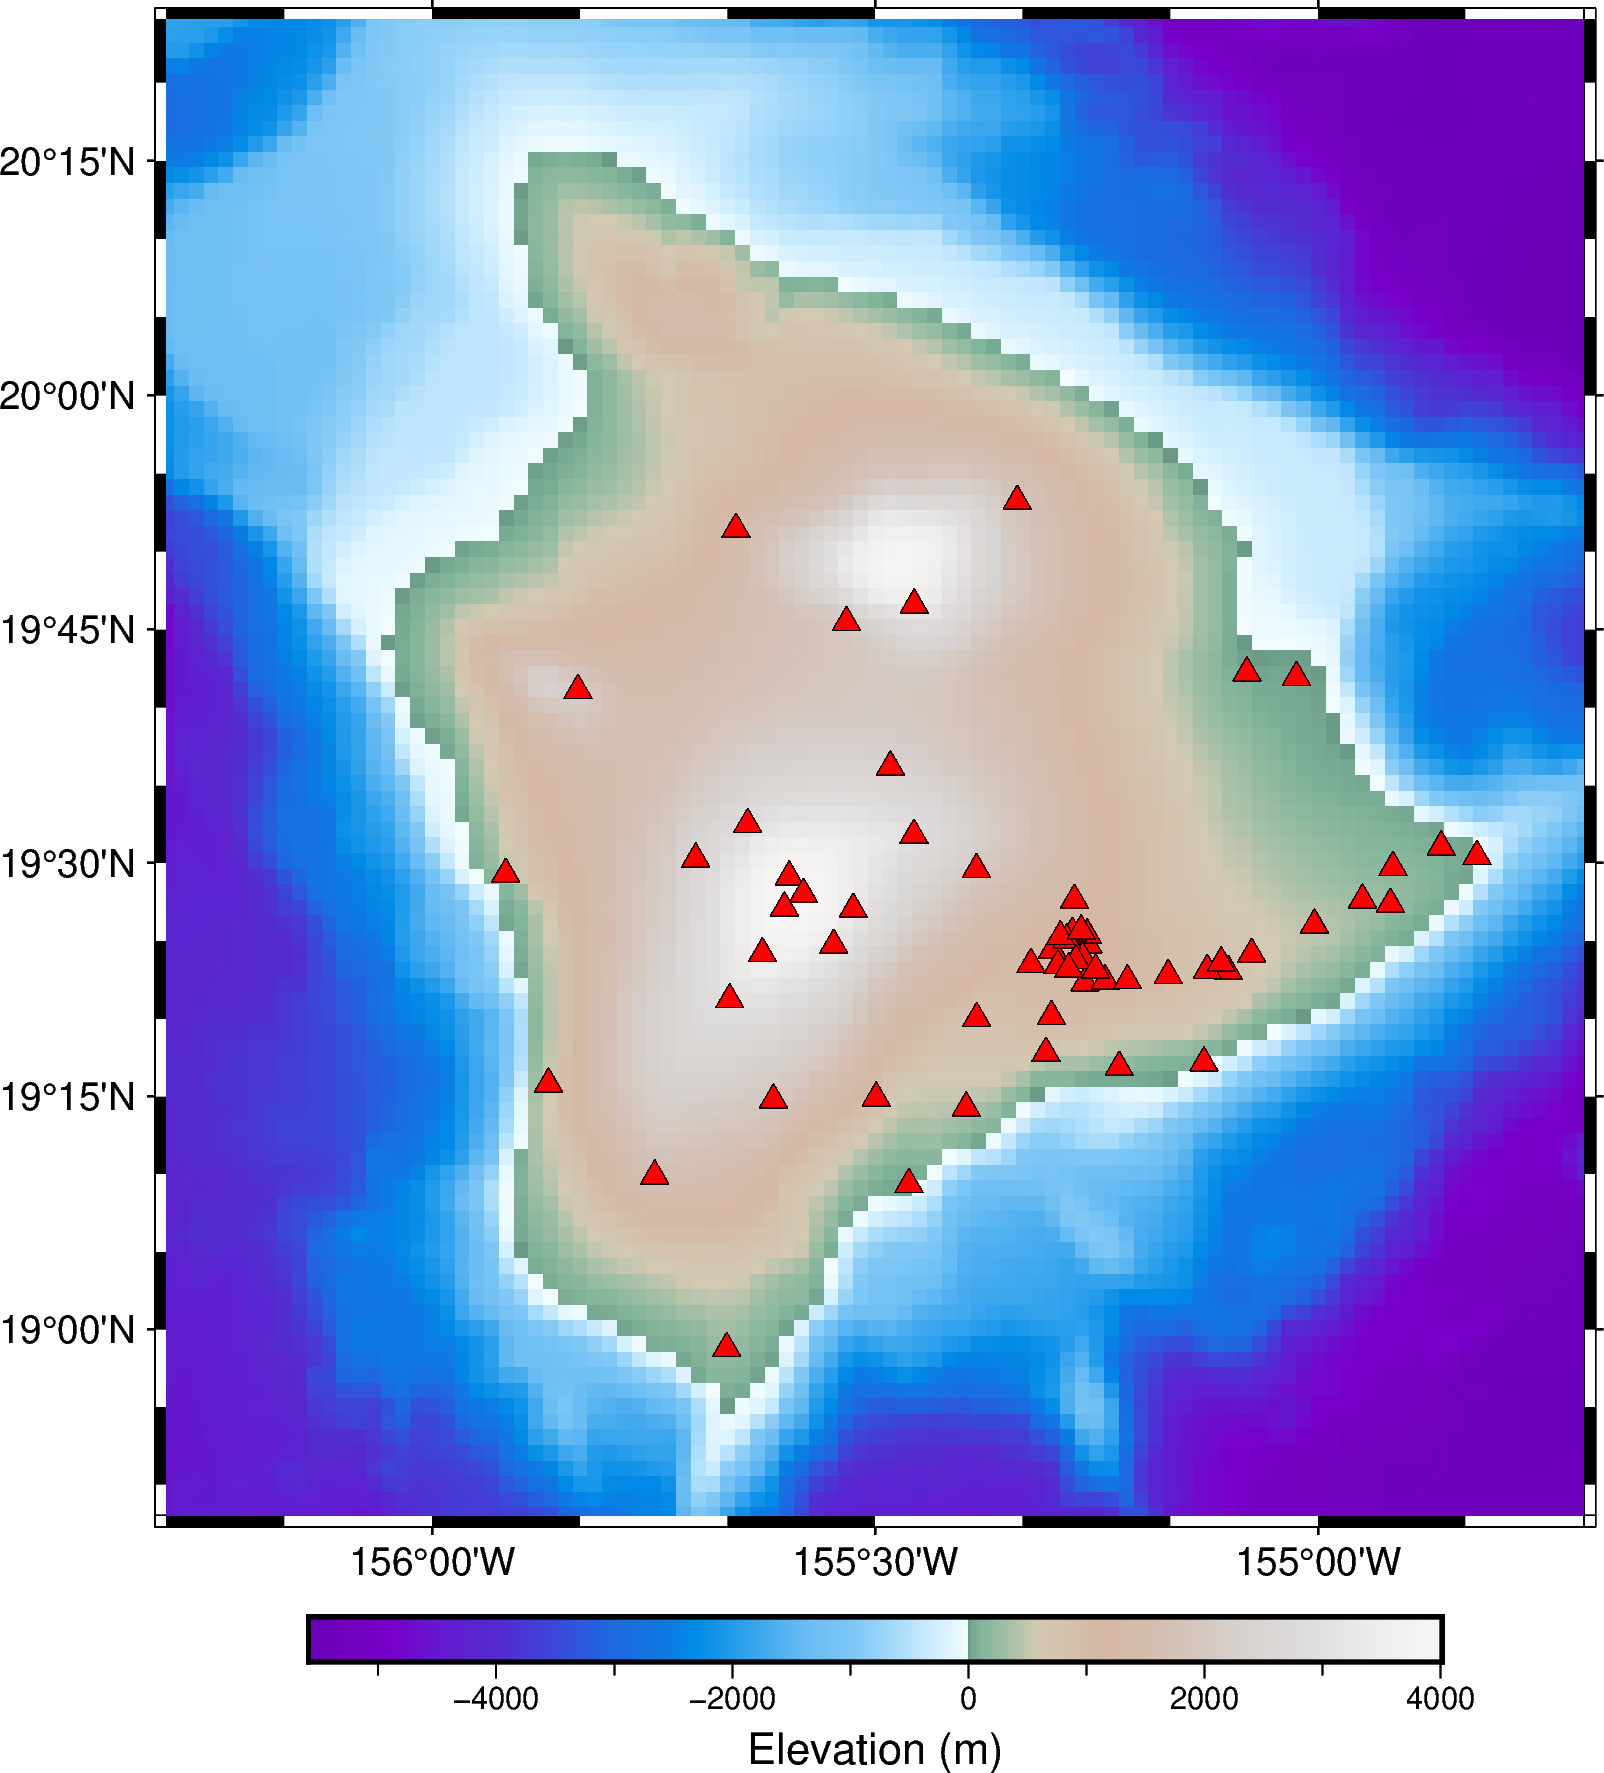

In [69]:
topo = xr.open_dataset("hawaii.nc")

fig = plot_basemap(region, feature=False)
fig.grdimage(grid="hawaii.nc", cmap="terra")
fig.plot(
    x=sr["stlo"],
    y=sr["stla"],
    style="t0.27c",
    fill="red",
    pen="0.1p,black",
)
fig.plot(
    x=sr["evlo"],
    y=sr["evla"],
    style="t0.27c",
    fill="red",
    pen="0.1p,black",
)
fig.colorbar(frame=["x+lElevation (m)"])
fig.show()

## Rotate stations

In [70]:
pos = [19.5, -155.5]
angle = -30

pos_str = f"{pos[0]}/{pos[1]}"
! ../../bin/surfatt_rotate_src_rec -i src_rec_file_raw.csv -a "$angle" -c "$pos_str" -o src_rec_file_rotated.csv

[2026-03-28 23:55:25.665] [SRCREC] [info] Loading source-receiver table from src_rec_file_raw.csv
[2026-03-28 23:55:25.697] [SRCREC] [info] Distributing event information to all ranks


In [ ]:
sr_rotated = pd.read_csv("src_rec_file_rotated.csv")
minx = sr_rotated["stlo"].min()
maxx = sr_rotated["stlo"].max()
miny = sr_rotated["stla"].min()
maxy = sr_rotated["stla"].max()
marginx = (maxx - minx) * 0.4
marginy = (maxy - miny) * 0.4
region_new = [minx - marginx, maxx + marginx, miny - marginy, maxy + marginy]


-0.4198 0.5586 -0.3714 0.3832


## Create grid in new coordinate system

In [75]:
import os

newx_min = minx - marginx
newy_min = miny - marginy
newx_max = maxx + marginx
newy_max = maxy + marginy

out_nc = 'hawaii_rotated.nc'
if os.path.exists(out_nc):
    os.remove(out_nc)

! ../../bin/SURFATT_rotate_topo -i hawaii.nc -a "$angle" -c "$pos_str" -x "$newx_min"/"$newx_max" -y "$newy_min"/"$newy_max" -o "$out_nc"

libc++abi: terminating due to uncaught exception of type std::runtime_error: Parallel: call init() first


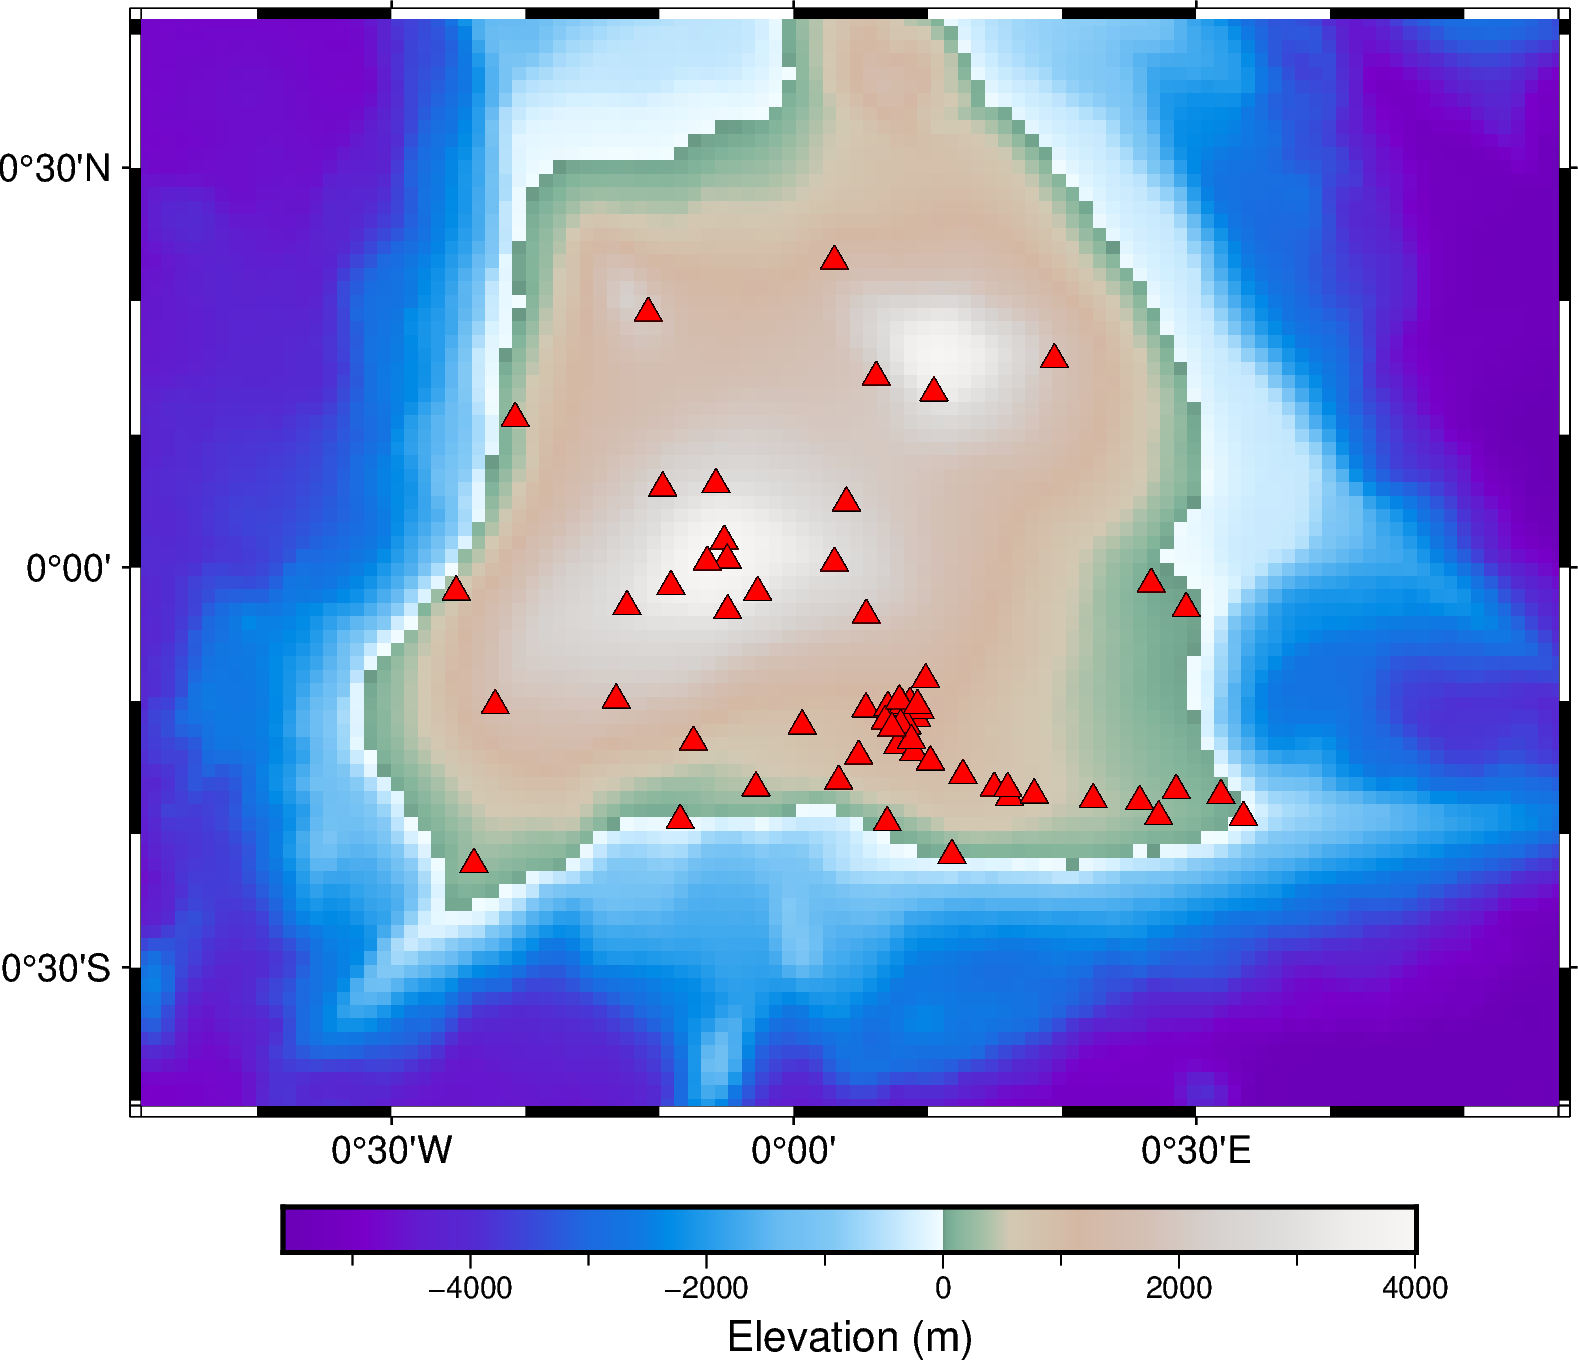

In [74]:
topo_rotated = xr.open_dataset("hawaii_rotated.nc")

lon = topo_rotated["lon"].values
lat = topo_rotated["lat"].values
z = topo_rotated["z"].values  # shape (nlon, nlat)
topo_rotated.close()
rot_grid = xr.DataArray(z.T, coords={"lat": lat, "lon": lon}, dims=["lat", "lon"])

fig = plot_basemap(region_new, feature=False)
fig.grdimage(grid=rot_grid, cmap="terra")
fig.plot(
    x=sr_rotated["stlo"],
    y=sr_rotated["stla"],
    style="t0.27c",
    fill="red",
    pen="0.1p,black",
)
fig.plot(
    x=sr_rotated["evlo"],
    y=sr_rotated["evla"],
    style="t0.27c",
    fill="red",
    pen="0.1p,black",
)
fig.colorbar(frame=["x+lElevation (m)"])
fig.show()